In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load the built-in MNIST dataset
mnist_nums = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist_nums.load_data()

# Reshape data to (num_samples, 28, 28, 1) and normalize pixel intensities
X_train = X_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
X_test = X_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")
print(f"Number of classes: {len(tf.unique(y_train)[0])}")  # should be 10

Training shape: (60000, 28, 28, 1), Testing shape: (10000, 28, 28, 1)
Number of classes: 10


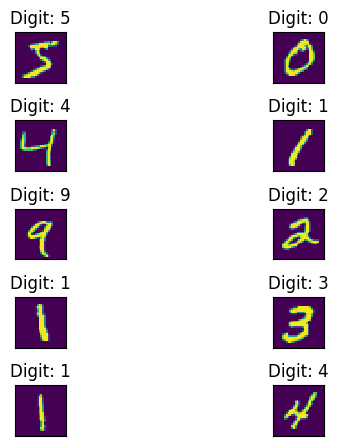

In [14]:
import matplotlib.pyplot as plt
fig = plt.figure()
for i in range(10):
  plt.subplot(5,2,i+1)
  plt.tight_layout()
  plt.imshow(X_train[i], interpolation='none')
  plt.title("Digit: {}".format(y_train[i]))
  plt.xticks([])
  plt.yticks([])

In [21]:
model = models.Sequential([
    # Convolutional layer extracts visual features (edges, curves)
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer for more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 2D matrices into a 1D vector
    layers.Flatten(),

    # Dense hidden layer
    layers.Dense(64, activation='relu'),

    # Output layer with 10 units (one for each digit 0-9)
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the network using a standard batch size
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9433 - loss: 0.1882 - val_accuracy: 0.9798 - val_loss: 0.0699
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9829 - loss: 0.0544 - val_accuracy: 0.9855 - val_loss: 0.0474
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9871 - loss: 0.0402 - val_accuracy: 0.9860 - val_loss: 0.0463
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9899 - loss: 0.0309 - val_accuracy: 0.9903 - val_loss: 0.0344
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9925 - loss: 0.0232 - val_accuracy: 0.9900 - val_loss: 0.0327


In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

313/313 - 0s - 1ms/step - accuracy: 0.9888 - loss: 0.0357

Final Test Accuracy: 98.88%


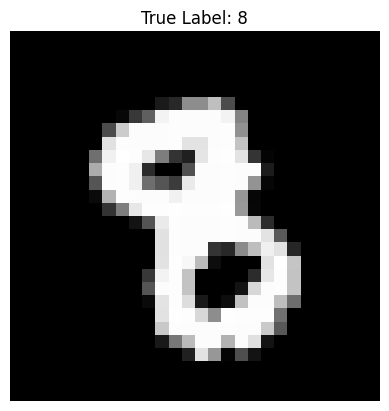

Predicted Digit: 8
Confidence: 100.00%

All probabilities:
0: 0.00%
1: 0.00%
2: 0.00%
3: 0.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 0.00%
8: 100.00%
9: 0.00%


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random test sample
idx = np.random.randint(0, len(X_test))

image = X_test[idx]
true_label = y_test[idx]

# Display the image
plt.imshow(image, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

# Prepare image for prediction
x = image.reshape(1, 28, 28)

# Get prediction probabilities
probs = model.predict(x, verbose=0)[0]

# Predicted digit
predicted_digit = np.argmax(probs)

print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {probs[predicted_digit]*100:.2f}%")

print("\nAll probabilities:")
for digit, prob in enumerate(probs):
    print(f"{digit}: {prob*100:.2f}%")

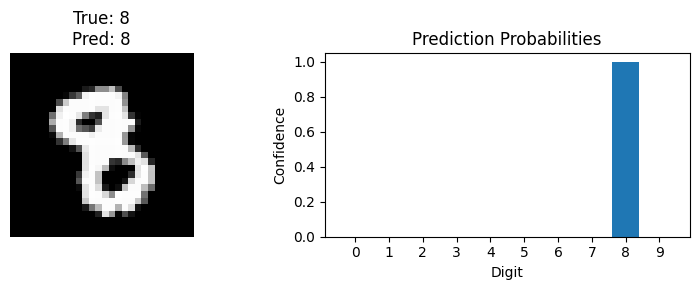

In [18]:
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title(f"True: {true_label}\nPred: {predicted_digit}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(10), probs)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Confidence")
plt.title("Prediction Probabilities")

plt.tight_layout()
plt.show()

In [23]:
model.save("mnist_model.keras")